In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Import models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load final features
X_train = pd.read_csv('data/processed/X_train_final.csv')
X_test = pd.read_csv('data/processed/X_test_final.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train.shape[0] if hasattr(y_train, 'shape') else len(y_train)}")
print(f"Test features: {X_test.shape}")
print(f"Test labels: {y_test.shape[0] if hasattr(y_test, 'shape') else len(y_test)}")
print(f"Features used: {list(X_train.columns)}")
print("\n✅ Data loaded successfully!")

Training features: (125973, 18)
Training labels: 125973
Test features: (22544, 18)
Test labels: 22544
Features used: ['same_srv_rate', 'src_bytes', 'dst_host_srv_count', 'flag', 'dst_host_same_srv_rate', 'logged_in', 'srv_serror_rate', 'serror_rate', 'dst_host_srv_serror_rate', 'dst_host_serror_rate', 'count', 'service', 'dst_bytes', 'diff_srv_rate', 'dst_host_diff_srv_rate', 'bytes_ratio', 'total_bytes', 'error_ratio']

✅ Data loaded successfully!


In [2]:
# Create dictionary of models to evaluate (SVM removed)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

print(f"📊 We will evaluate {len(models)} models:")
for name in models.keys():
    print(f"  • {name}")

📊 We will evaluate 6 models:
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • K-Nearest Neighbors
  • Gradient Boosting
  • XGBoost


In [14]:
# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get probability predictions for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc if roc_auc else 'N/A'
    })
    
    # Store trained model for later use
    trained_models[name] = model
    
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   F1-Score: {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))


🔍 Training Logistic Regression...
   Accuracy: 0.7264
   F1-Score: 0.7062

🔍 Training Decision Tree...
   Accuracy: 0.7662
   F1-Score: 0.7508

🔍 Training Random Forest...
   Accuracy: 0.7770
   F1-Score: 0.7637

🔍 Training K-Nearest Neighbors...
   Accuracy: 0.7995
   F1-Score: 0.7922

🔍 Training Gradient Boosting...
   Accuracy: 0.7768
   F1-Score: 0.7628

🔍 Training XGBoost...
   Accuracy: 0.7964
   F1-Score: 0.7879

MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.726402   0.908445 0.577573  0.706174 0.877471
      Decision Tree  0.766235   0.954781 0.618639  0.750804 0.793219
      Random Forest  0.776969   0.961998 0.633211  0.763722 0.954264
K-Nearest Neighbors  0.799503   0.965923 0.671472  0.792222 0.839331
  Gradient Boosting  0.776792   0.965176 0.630640  0.762843 0.955800
            XGBoost  0.796443   0.968196 0.664225  0.787910 0.968800


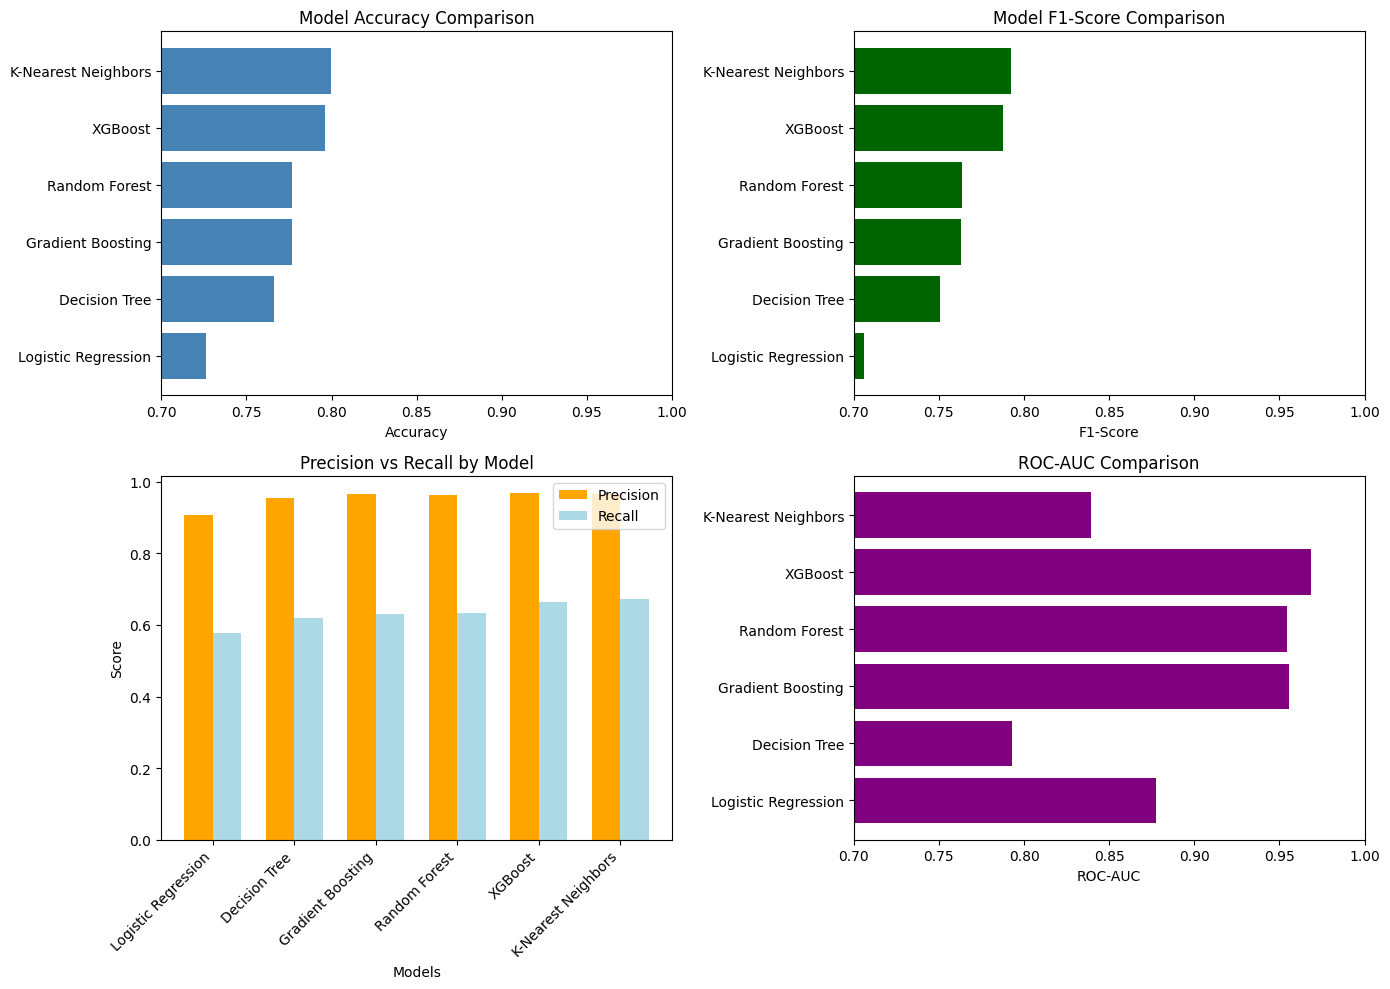

In [4]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sort results by F1-Score
results_df_sorted = results_df.sort_values('F1-Score', ascending=True)

# 1. Accuracy comparison
axes[0,0].barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='steelblue')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_xlim(0.7, 1.0)

# 2. F1-Score comparison
axes[0,1].barh(results_df_sorted['Model'], results_df_sorted['F1-Score'], color='darkgreen')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].set_title('Model F1-Score Comparison')
axes[0,1].set_xlim(0.7, 1.0)

# 3. Precision vs Recall comparison
x = np.arange(len(results_df_sorted))
width = 0.35
axes[1,0].bar(x - width/2, results_df_sorted['Precision'], width, label='Precision', color='orange')
axes[1,0].bar(x + width/2, results_df_sorted['Recall'], width, label='Recall', color='lightblue')
axes[1,0].set_xlabel('Models')
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('Precision vs Recall by Model')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(results_df_sorted['Model'], rotation=45, ha='right')
axes[1,0].legend()

# 4. ROC-AUC comparison (for models that support it)
roc_models = results_df_sorted[results_df_sorted['ROC-AUC'] != 'N/A']
if len(roc_models) > 0:
    axes[1,1].barh(roc_models['Model'], roc_models['ROC-AUC'].astype(float), color='purple')
    axes[1,1].set_xlabel('ROC-AUC')
    axes[1,1].set_title('ROC-AUC Comparison')
    axes[1,1].set_xlim(0.7, 1.0)
else:
    axes[1,1].text(0.5, 0.5, 'ROC-AUC not available for all models', 
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.savefig('exports/plots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Identify the best model based on F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = trained_models[best_model_name]
best_f1 = results_df['F1-Score'].max()

print(" BEST MODEL")
print("="*60)
print(f"Best model: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"Accuracy: {results_df.loc[results_df['Model']==best_model_name, 'Accuracy'].values[0]:.4f}")
print(f"Precision: {results_df.loc[results_df['Model']==best_model_name, 'Precision'].values[0]:.4f}")
print(f"Recall: {results_df.loc[results_df['Model']==best_model_name, 'Recall'].values[0]:.4f}")

 BEST MODEL
Best model: K-Nearest Neighbors
F1-Score: 0.7922
Accuracy: 0.7995
Precision: 0.9659
Recall: 0.6715


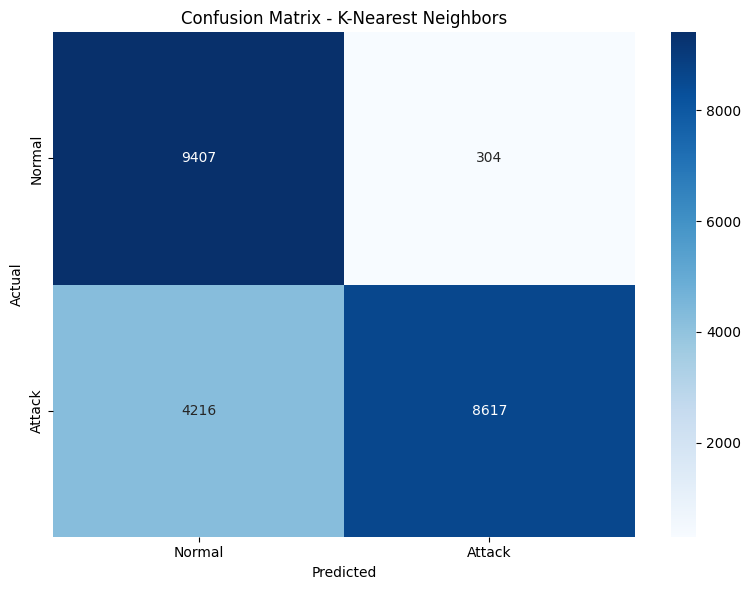

CONFUSION MATRIX BREAKDOWN
True Negatives (Correctly predicted Normal): 9407
False Positives (Normal misclassified as Attack): 304
False Negatives (Attack misclassified as Normal): 4216
True Positives (Correctly predicted Attack): 8617

Detection Rate (TPR): 0.6715
False Alarm Rate (FPR): 0.0313

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9711
      Attack       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



In [6]:
# Get predictions from best model
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('exports/plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate TP, TN, FP, FN
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Negatives (Correctly predicted Normal): {tn}")
print(f"False Positives (Normal misclassified as Attack): {fp}")
print(f"False Negatives (Attack misclassified as Normal): {fn}")
print(f"True Positives (Correctly predicted Attack): {tp}")
print(f"\nDetection Rate (TPR): {tp/(tp+fn):.4f}")
print(f"False Alarm Rate (FPR): {fp/(fp+tn):.4f}")

# Detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Attack']))

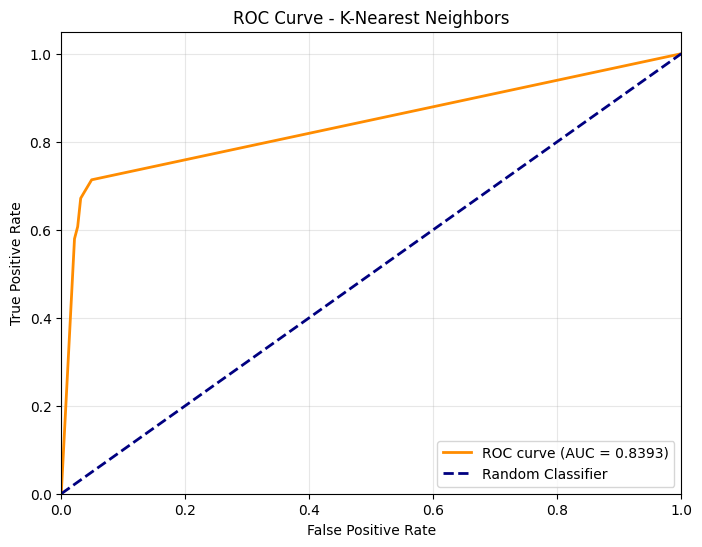

Best threshold: 0.200
F1-Score at best threshold: 0.8151


In [7]:
# ROC Curve for best model
if hasattr(best_model, 'predict_proba'):
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
    roc_auc = roc_auc_score(y_test, y_prob_best)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('exports/plots/roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find best threshold (maximize F1)
    best_f1_score = 0
    best_threshold = 0.5
    
    for thresh in thresholds:
        y_pred_thresh = (y_prob_best >= thresh).astype(int)
        f1_thresh = f1_score(y_test, y_pred_thresh)
        if f1_thresh > best_f1_score:
            best_f1_score = f1_thresh
            best_threshold = thresh
    
    print(f"Best threshold: {best_threshold:.3f}")
    print(f"F1-Score at best threshold: {best_f1_score:.4f}")

CROSS-VALIDATION RESULTS
Fold 1: 0.9909
Fold 2: 0.9906
Fold 3: 0.9905
Fold 4: 0.9903
Fold 5: 0.9914

Mean F1-Score: 0.9907
Std Dev: 0.0004
95% Confidence Interval: (0.9900, 0.9915)


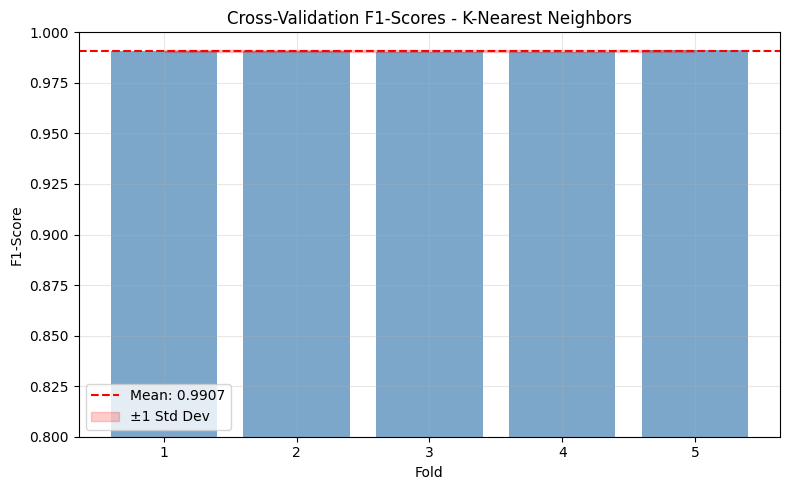

In [8]:
# Perform cross-validation to ensure model is stable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1')

print("CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Fold 1: {cv_scores[0]:.4f}")
print(f"Fold 2: {cv_scores[1]:.4f}")
print(f"Fold 3: {cv_scores[2]:.4f}")
print(f"Fold 4: {cv_scores[3]:.4f}")
print(f"Fold 5: {cv_scores[4]:.4f}")
print(f"\nMean F1-Score: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: ({cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f})")

# Visualize cross-validation results
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='red', label=f'±1 Std Dev')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.title(f'Cross-Validation F1-Scores - {best_model_name}')
plt.xticks(range(1, 6))
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exports/plots/cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Check if best model can provide feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("FEATURE IMPORTANCE FROM BEST MODEL")
    print("="*60)
    print(feature_importance_df)
    
    # Visualize
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['feature'].head(15), 
             feature_importance_df['importance'].head(15), 
             color='darkgreen')
    plt.xlabel('Importance')
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('exports/plots/best_model_features.png', dpi=300, bbox_inches='tight')
    plt.show()
    
elif best_model_name == 'Logistic Regression':
    # For logistic regression, coefficients show feature importance
    coefs = best_model.coef_[0]
    coef_df = pd.DataFrame({
        'feature': X_train.columns,
        'coefficient': np.abs(coefs)
    }).sort_values('coefficient', ascending=False)
    print("FEATURE COEFFICIENTS (Absolute values)")
    print("="*60)
    print(coef_df)
else:
    print(f"Feature importance not available for {best_model_name}")

Feature importance not available for K-Nearest Neighbors


In [12]:
# Save the best model for future use
import joblib
import datetime

# Save model with timestamp
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'models/best_model_{best_model_name.replace(" ", "_")}_{timestamp}.pkl'
joblib.dump(best_model, model_filename)

# Also save as 'latest' for easy access
joblib.dump(best_model, 'models/best_model_latest.pkl')

# Save results summary
results_df.to_csv('results/model_comparison_results.csv', index=False)

print(" MODEL BUILDING COMPLETE! ")
print("="*60)
print(f"Best model: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"Model saved to: {model_filename}")
print(f"Results saved to: results/model_comparison_results.csv")
print("\n Visualizations saved to exports/plots/")

 MODEL BUILDING COMPLETE! 
Best model: K-Nearest Neighbors
F1-Score: 0.7922
Model saved to: models/best_model_K-Nearest_Neighbors_20260225_195127.pkl
Results saved to: results/model_comparison_results.csv

 Visualizations saved to exports/plots/
